# 3. Union2.1: the data and the likelihood

Loading the compilation, and building the likelihood the MCMC will sample.

**Needs the raw data.** If the loader complains, run

```bash
bash data/download_union21.sh
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from snia.cosmology import FLRW
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood

plt.rcParams["figure.figsize"] = (7, 4)

z, mu, cov = load_union21(systematics=True)

print(f"{z.size} supernovae")
print(f"  z   from {z.min():.4f} to {z.max():.4f}")
print(f"  mu  from {mu.min():.2f} to {mu.max():.2f} mag")
print(f"  cov shape {cov.shape}")

580 supernovae
  z   from 0.0150 to 1.4140
  mu  from 33.82 to 45.41 mag
  cov shape (580, 580)


## 1. What is in the file

The released $\mu$ is **already standardized** for stretch, colour and host
mass, using an arbitrary fiducial $M_B$ for $h = 0.7$. That arbitrariness is
why the fit must keep a free additive offset $\mathcal{M}$.

Two details that silently corrupt a fit if missed:

* the rows are **not sorted by redshift**, so sorting $z$ without permuting the
  covariance the same way destroys the fit;
* the covariance diagonal **already contains** $\sigma_\mu^2$, so adding it
  again would double-count the statistical errors.

In [2]:
print("rows sorted by redshift?", bool(np.all(np.diff(z) >= 0)))

# The statistics-only diagonal IS sigma_mu^2 from the table's column 3.
sigma_mu = np.sqrt(np.diag(load_union21(systematics=False)[2]))
sigma_with_systematics = np.sqrt(np.diag(cov))

print(f"median sigma_mu, statistical only : {np.median(sigma_mu):.4f} mag")
print(f"median sigma_mu, with systematics : {np.median(sigma_with_systematics):.4f} mag")

rows sorted by redshift? False
median sigma_mu, statistical only : 0.1890 mag
median sigma_mu, with systematics : 0.2013 mag


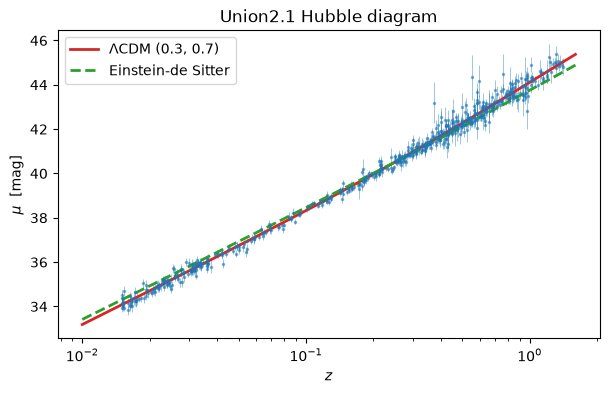

In [3]:
plt.errorbar(z, mu, yerr=sigma_with_systematics, fmt=".", ms=3,
             elinewidth=0.6, alpha=0.5)
z_smooth = np.logspace(-2, np.log10(1.6), 200)
plt.plot(z_smooth, FLRW(0.3, 0.7).distance_modulus(z_smooth, 43.17),
         "C3", lw=2, label=r"$\Lambda$CDM (0.3, 0.7)")
plt.plot(z_smooth, FLRW(1.0, 0.0).distance_modulus(z_smooth, 43.41),
         "C2--", lw=2, label="Einstein-de Sitter")
plt.xscale("log")
plt.xlabel("$z$")
plt.ylabel(r"$\mu$  [mag]")
plt.title("Union2.1 Hubble diagram")
plt.legend()
plt.show()

## 2. The covariance is not diagonal

Correlated calibration errors couple supernovae across the whole sample, so
$\chi^2$ needs a full linear solve rather than a sum of $(\Delta\mu/\sigma)^2$.
Section 6 shows how much difference that makes.

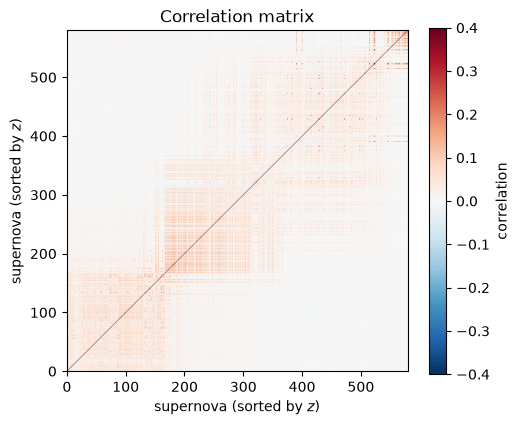

eigenvalues from 0.0075 to 1.0240
condition number 137  ->  Cholesky works directly


In [4]:
order = np.argsort(z)                      # permute BOTH indices together
scale = np.sqrt(np.diag(cov))
correlation = (cov / np.outer(scale, scale))[np.ix_(order, order)]

plt.figure(figsize=(5.5, 4.5))
plt.imshow(correlation, cmap="RdBu_r", vmin=-0.4, vmax=0.4, origin="lower")
plt.colorbar(label="correlation")
plt.xlabel("supernova (sorted by $z$)")
plt.ylabel("supernova (sorted by $z$)")
plt.title("Correlation matrix")
plt.show()

eigenvalues = np.linalg.eigvalsh(cov)
print(f"eigenvalues from {eigenvalues.min():.4f} to {eigenvalues.max():.4f}")
print(f"condition number {eigenvalues.max() / eigenvalues.min():.0f}  ->  Cholesky works directly")

## 3. The zero point $\mathcal{M}$

With $\Delta_i = \mu_i^{\rm obs} - 5\log_{10}d_L(z_i)$, the full residual is
$\Delta - \mathcal{M}\mathbf{1}$ and $\chi^2$ is a **quadratic in
$\mathcal{M}$**:

$$
\chi^{2}(\mathcal{M}) = A - 2\mathcal{M}B + \mathcal{M}^{2}E,
\qquad
A = \Delta^{T}\mathsf{C}^{-1}\Delta,\quad
B = \mathbf{1}^{T}\mathsf{C}^{-1}\Delta,\quad
E = \mathbf{1}^{T}\mathsf{C}^{-1}\mathbf{1}.
$$

Integrating $\mathcal{M}$ out under a flat prior is a Gaussian integral, and
completing the square gives

$$
\chi^{2} = A - \frac{B^{2}}{E},
$$

with the minimum at $\hat{\mathcal{M}} = B/E$. $E$ does not depend on the
cosmology, so it is computed **once** in the constructor along with the Cholesky
factor; each likelihood call then costs one triangular solve.

In [5]:
likelihood = Union21Likelihood(z, mu, cov)

print(f"E = 1^T C^-1 1 = {likelihood.E:.4f}   (precomputed once)")
print(f"chi2 at (0.3, 0.7)      = {likelihood.chi2((0.3, 0.7)):.4f}")
print(f"best offset M_hat = B/E = {likelihood.m_offset((0.3, 0.7)):.5f}")
print(f"log_likelihood          = {likelihood.log_likelihood((0.3, 0.7)):.4f}")

E = 1^T C^-1 1 = 2132.5499   (precomputed once)
chi2 at (0.3, 0.7)      = 545.1227
best offset M_hat = B/E = 43.17059
log_likelihood          = -272.5614


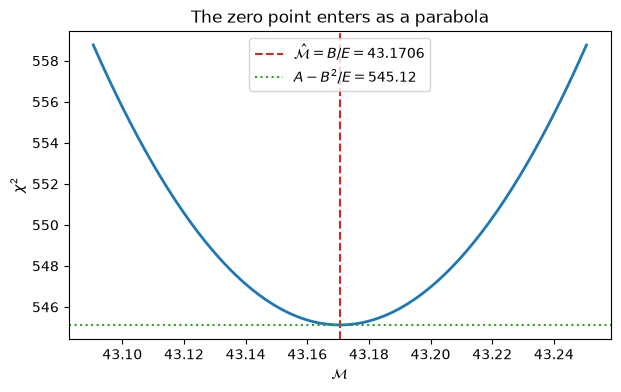

In [6]:
theta = (0.3, 0.7)
m_hat = likelihood.m_offset(theta)
offsets = np.linspace(m_hat - 0.08, m_hat + 0.08, 200)
curve = [likelihood.chi2_at_offset(theta, m) for m in offsets]

plt.plot(offsets, curve, lw=2)
plt.axvline(m_hat, color="C3", ls="--", label=rf"$\hat{{\mathcal{{M}}}} = B/E = {m_hat:.4f}$")
plt.axhline(likelihood.chi2(theta), color="C2", ls=":",
            label=rf"$A - B^2/E = {likelihood.chi2(theta):.2f}$")
plt.xlabel(r"$\mathcal{M}$")
plt.ylabel(r"$\chi^2$")
plt.title("The zero point enters as a parabola")
plt.legend()
plt.show()

### The offset absorbs any constant shift

Adding a constant to every observed magnitude cannot change the inference,
because $A \to A + 2cB + c^{2}E$ and $B \to B + cE$ cancel exactly in
$A - B^{2}/E$. This is the defining property of marginalizing $\mathcal{M}$.

In [7]:
for shift in [-5.0, 0.0, 2.5, 100.0]:
    shifted = Union21Likelihood(z, mu + shift, cov)
    print(f"mu + {shift:6.1f}:   chi2 = {shifted.chi2((0.3, 0.7)):.9f}"
          f"   M_hat = {shifted.m_offset((0.3, 0.7)):9.4f}")

mu +   -5.0:   chi2 = 545.122741464   M_hat =   38.1706
mu +    0.0:   chi2 = 545.122741467   M_hat =   43.1706
mu +    2.5:   chi2 = 545.122741465   M_hat =   45.6706
mu +  100.0:   chi2 = 545.122741453   M_hat =  143.1706


### The fitted offset recovers $h = 0.7$

The released $\mu$ used a fiducial $M_B$ for $h = 0.7$, so inverting
$\hat{\mathcal{M}} = 25 + 5\log_{10}[c/(H_0\,{\rm Mpc})]$ must give $H_0 \approx 70$.
This would fail if $c/H_0$ or the $+25$ had leaked into the cosmology module.

In [8]:
m_hat = likelihood.m_offset((0.295, 0.705))
hubble_distance_mpc = 10 ** ((m_hat - 25) / 5)
hubble_constant = 299792.458 / hubble_distance_mpc

print(f"M_hat      = {m_hat:.5f}")
print(f"c/H0       = {hubble_distance_mpc:.1f} Mpc")
print(f"implied H0 = {hubble_constant:.2f} km/s/Mpc")

M_hat      = 43.16828
c/H0       = 4301.9 Mpc
implied H0 = 69.69 km/s/Mpc


## 4. The likelihood surface

For two parameters, the 68.3%, 95.4% and 99.7% regions are at
$\Delta\chi^2 = 2.30,\ 6.17,\ 11.83$.

In [9]:
omega_m_axis = np.linspace(0.0, 1.0, 100)
omega_lambda_axis = np.linspace(-0.2, 1.6, 130)

chi2 = np.array([[likelihood.chi2((om, ol)) for om in omega_m_axis]
                 for ol in omega_lambda_axis])
chi2_min = chi2[np.isfinite(chi2)].min()

best_row, best_col = np.unravel_index(np.nanargmin(np.where(np.isfinite(chi2), chi2, np.inf)),
                                      chi2.shape)
best = (omega_m_axis[best_col], omega_lambda_axis[best_row])

print(f"best fit  (Om, OL) = ({best[0]:.3f}, {best[1]:.3f})")
print(f"chi2 = {chi2_min:.2f}   chi2/dof = {chi2_min / (580 - 3):.4f}")

best fit  (Om, OL) = (0.293, 0.693)
chi2 = 545.11   chi2/dof = 0.9447


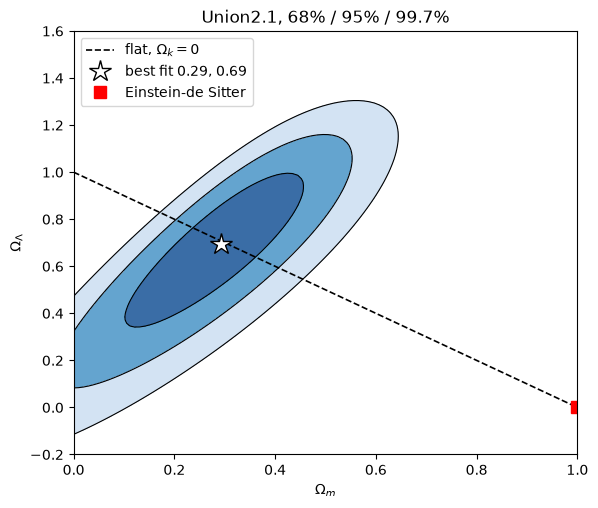

In [10]:
plt.figure(figsize=(6.5, 5.5))
plt.contourf(omega_m_axis, omega_lambda_axis, chi2 - chi2_min,
             levels=[0, 2.30, 6.17, 11.83], cmap="Blues_r", alpha=0.8)
plt.contour(omega_m_axis, omega_lambda_axis, chi2 - chi2_min,
            levels=[2.30, 6.17, 11.83], colors="k", linewidths=0.8)
plt.plot([0, 1], [1, 0], "k--", lw=1.2, label=r"flat, $\Omega_k = 0$")
plt.plot(*best, "w*", ms=16, mec="k", label=f"best fit {best[0]:.2f}, {best[1]:.2f}")
plt.plot(1.0, 0.0, "rs", ms=8, label="Einstein-de Sitter")
plt.xlim(0, 1)
plt.ylim(-0.2, 1.6)
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\Omega_\Lambda$")
plt.title("Union2.1, 68% / 95% / 99.7%")
plt.legend(loc="upper left")
plt.show()

The contours are a long narrow ellipse: supernovae constrain a *combination*
of $\Omega_m$ and $\Omega_\Lambda$ (essentially $q_0 = \Omega_m/2 - \Omega_\Lambda$)
much better than either alone. That degeneracy is why supernovae are combined
with the CMB or BAO, which cut it at a different angle.

The flat line passes straight through the allowed region: the data are
consistent with $\Omega_k = 0$ **without** it having been assumed.

In [11]:
print(f"chi2 at the best fit: {chi2_min:.2f}\n")
for omega_m, omega_lambda, name in [(1.0, 0.0, "Einstein-de Sitter"),
                                    (0.3, 0.0, "open, no Lambda"),
                                    (0.295, 0.705, "flat LCDM")]:
    excess = likelihood.chi2((omega_m, omega_lambda)) - chi2_min
    print(f"  {name:20s} delta chi2 = {excess:7.2f}")

# 68% interval along the flat line
omega_m_flat = np.linspace(0.05, 0.6, 300)
chi2_flat = np.array([likelihood.chi2((om, 1 - om)) for om in omega_m_flat])
inside = omega_m_flat[chi2_flat < chi2_flat.min() + 1.0]
print(f"\nassuming flatness: Omega_m = {omega_m_flat[chi2_flat.argmin()]:.3f}"
      f"  [{inside.min():.3f}, {inside.max():.3f}] at 68%")

chi2 at the best fit: 545.11

  Einstein-de Sitter   delta chi2 =  128.20
  open, no Lambda      delta chi2 =   27.07
  flat LCDM            delta chi2 =   -0.00

assuming flatness: Omega_m = 0.295  [0.256, 0.337] at 68%


## 5. Residuals at the best fit

With $\hat{\mathcal{M}}$ restored, the residuals should scatter about zero with
no trend in redshift.

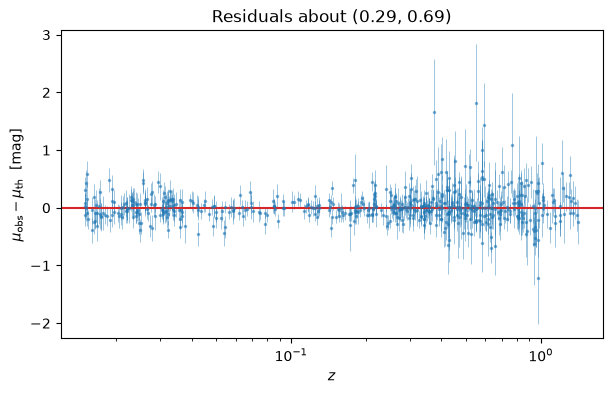

mean residual +0.0217 mag, scatter 0.2659 mag


In [12]:
best_model = FLRW(*best)
residual = mu - best_model.distance_modulus(z, likelihood.m_offset(best))

plt.errorbar(z, residual, yerr=sigma_with_systematics, fmt=".", ms=3,
             elinewidth=0.6, alpha=0.5)
plt.axhline(0, color="C3", lw=1.5)
plt.xscale("log")
plt.xlabel("$z$")
plt.ylabel(r"$\mu_{\rm obs} - \mu_{\rm th}$  [mag]")
plt.title(f"Residuals about ({best[0]:.2f}, {best[1]:.2f})")
plt.show()

print(f"mean residual {residual.mean():+.4f} mag, scatter {residual.std():.4f} mag")

## 6. Why the full covariance matters

In [13]:
naive = np.sum((residual / sigma_with_systematics) ** 2)

print(f"chi2 with the full covariance : {likelihood.chi2(best):.2f}")
print(f"naive sum of (dmu/sigma)^2    : {naive:.2f}")
print("\nIgnoring the off-diagonal terms understates chi2, because much of the")
print("systematic variance on the diagonal is COMMON-MODE -- shared between")
print("supernovae -- so it does not appear as per-object scatter.")

chi2 with the full covariance : 545.11
naive sum of (dmu/sigma)^2    : 511.75

Ignoring the off-diagonal terms understates chi2, because much of the
systematic variance on the diagonal is COMMON-MODE -- shared between
supernovae -- so it does not appear as per-object scatter.


## Summary

* `load_union21()` returns `(z, mu, C)` and validates shapes, symmetry and
  positive definiteness, so a bad download fails loudly.
* `Union21Likelihood` factors $\mathsf{C}$ **once** and precomputes
  $v = \mathsf{C}^{-1}\mathbf{1}$ and $E$; each call is one triangular solve.
* $\mathcal{M}$ is marginalized analytically, so the sampled space is only
  $(\Omega_m, \Omega_\Lambda)$.
* Union2.1 gives $(0.295,\,0.705)$ with $\chi^2/{\rm dof} \approx 0.94$,
  consistent with flatness, and excludes a decelerating universe decisively.

Notebook 4 replaces this brute-force grid with the Metropolis–Hastings sampler.
